In [1]:
import pandas as pd
import time
import re
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor

In [2]:
df = pd.read_csv('model_df.csv')

In [3]:
#df.columns.tolist()

In [4]:
# Efficiency Stats
df['Passing_Yards_per_Attempt'] = df['Passing_Yds_prev1'] / df['Passing_Att_prev1'].replace(0, np.nan)
df['Rushing_Yards_per_Att'] = df['Rushing_Yds_prev1'] / df['Rushing_Att_prev1'].replace(0, np.nan)
df['Receiving_Yards_per_Rec'] = df['Receiving_Yds_prev1'] / df['Receiving_Rec_prev1'].replace(0, np.nan)

# Total Touches
df['Total_Touches'] = df['Rushing_Att_prev1'] + df['Receiving_Rec_prev1']

# Total Yards
df['Total_Yards'] = df['Rushing_Yds_prev1'] + df['Receiving_Yds_prev1'] + df['Passing_Yds_prev1']

# Touchdowns per Game
df['Total_TDs'] = df['Rushing_TD_prev1'] + df['Receiving_TD_prev1'] + df['Passing_TD_prev1']
df['TDs_per_Game'] = df['Total_TDs'] / df['Games_G_prev1'].replace(0, np.nan)

# Fumbles per Touch
df['Total_Attempts'] = df['Rushing_Att_prev1'] + df['Receiving_Rec_prev1'] + df['Passing_Att_prev1']
df['Fumbles_per_Touch'] = df['Fumbles_FL_prev1'] / df['Total_Attempts'].replace(0, np.nan)

# Total Scoring Plays
df['Total_Scoring_Plays'] = df['Scoring_TD_prev1'] + df['Scoring_2PM_prev1'] + df['Scoring_2PP_prev1']

In [5]:
# Calculate total touchdowns from previous season
df['Total_TD_prev1'] = df['Rushing_TD_prev1'] + df['Receiving_TD_prev1']

# Calculate total touches from previous season
df['Touches_prev1'] = df['Rushing_Att_prev1'] + df['Receiving_Rec_prev1']

# Compute touchdowns per touch, handling division by zero
df['TDs_per_Touch_prev1'] = df['Total_TD_prev1'] / df['Touches_prev1']
df['TDs_per_Touch_prev1'].replace([np.inf, -np.inf], np.nan, inplace=True)

C:\Users\nbrya\AppData\Local\Temp\ipykernel_19176\750058902.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TDs_per_Touch_prev1'].replace([np.inf, -np.inf], np.nan, inplace=True)


In [6]:
#df.head()

In [7]:
df.to_csv('df_features.csv', index=False)

In [8]:
# One-hot encode the FantPos column
position_dummies = pd.get_dummies(df['FantPos'], prefix='Pos')

In [9]:
# Add encoded columns to df
df = pd.concat([df, position_dummies], axis=1)

In [10]:
#df.head()

In [11]:
df['Changed_Teams'] = (df['Tm'] != df['Tm_prev1']).astype(int)

In [12]:
#df.head()

In [13]:
#df.to_csv('df_features.csv', index=False)

In [14]:
#df.columns.tolist()

In [15]:
# Define your predictors (you can add/remove as needed)
predictor_columns = [
     'Age_prev1',
     'Games_G_prev1',
     'Games_GS_prev1',
     'Passing_Cmp_prev1',
     'Passing_Att_prev1',
     'Passing_Yds_prev1',
     'Passing_TD_prev1',
     'Passing_Int_prev1',
     'Rushing_Att_prev1',
     'Rushing_Yds_prev1',
     'Rushing_TD_prev1',
     'Rushing_Y/A_prev1',
     'Receiving_Tgt_prev1',
     'Receiving_Rec_prev1',
     'Receiving_Yds_prev1',
     'Receiving_TD_prev1',
     'Receiving_Y/R_prev1',
     'Fumbles_Fmb_prev1',
     'Fumbles_FL_prev1',
     'Scoring_TD_prev1',
     'Fantasy_FantPt_prev1',
     'Passing_Yards_per_Attempt',
     'Rushing_Yards_per_Att',
     'Receiving_Yards_per_Rec',
     'TDs_per_Touch_prev1',
     'Total_Touches',
     'Fumbles_per_Touch',
     'Changed_Teams',
     'Pos_QB',
     'Pos_RB',
     'Pos_WR',
     'Pos_TE'
]

In [16]:
X = df[predictor_columns]

In [17]:
y = df['Fantasy_FantPt']

In [18]:
X_filled = X.fillna(0)

In [19]:
# Use the cleaned feature matrix
X_clean = X.fillna(0)  # or use the version you've already prepared

In [20]:
# Step 1: Drop rows where target is NaN
df_model = X_clean.copy()
df_model['Fantasy_FantPt'] = y
df_model = df_model.dropna(subset=['Fantasy_FantPt'])

In [21]:
# Step 2: Separate clean X and y
X_final = df_model.drop(columns='Fantasy_FantPt')
y_final = df_model['Fantasy_FantPt']

In [22]:
# Step 3: Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42
)

In [23]:
# Step 4: Train Linear Regression model
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [24]:
# Step 5: Predict and evaluate
y_pred = lr.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"Linear Regression R²: {r2:.4f}")
print(f"Linear Regression MAE: {mae:.2f}")

Linear Regression R²: 0.5583
Linear Regression MAE: 34.35


In [25]:
# Initialize the model
xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

In [26]:
# Fit the model
xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=-1, num_parallel_tree=None, ...)

In [27]:
# Predict on test set
y_pred_xgb = xgb.predict(X_test)

In [28]:
# Evaluate performance
r2_xgb = r2_score(y_test, y_pred_xgb)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)

print(f"XGBoost R²: {r2_xgb:.4f}")
print(f"XGBoost MAE: {mae_xgb:.2f}")

XGBoost R²: 0.5607
XGBoost MAE: 34.19


In [29]:
# Initialize KNN Regressor
knn = KNeighborsRegressor(n_neighbors=5, n_jobs=-1)

In [30]:
# Fit the model
knn.fit(X_train, y_train)

KNeighborsRegressor(n_jobs=-1)

In [31]:
# Predict on test set
y_pred_knn = knn.predict(X_test)

In [32]:
# Evaluate performance
r2_knn = r2_score(y_test, y_pred_knn)
mae_knn = mean_absolute_error(y_test, y_pred_knn)

print(f"KNN R²: {r2_knn:.4f}")
print(f"KNN MAE: {mae_knn:.2f}")

KNN R²: 0.4321
KNN MAE: 38.26


In [33]:
# Initialize Random Forest
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

In [34]:
# Train the model
rf.fit(X_train, y_train)

RandomForestRegressor(n_jobs=-1, random_state=42)

In [35]:
# Predict on the test set
y_pred_rf = rf.predict(X_test)

In [36]:
# Evaluate
r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print(f"Random Forest R²: {r2_rf:.4f}")
print(f"Random Forest MAE: {mae_rf:.2f}")

Random Forest R²: 0.5706
Random Forest MAE: 34.16


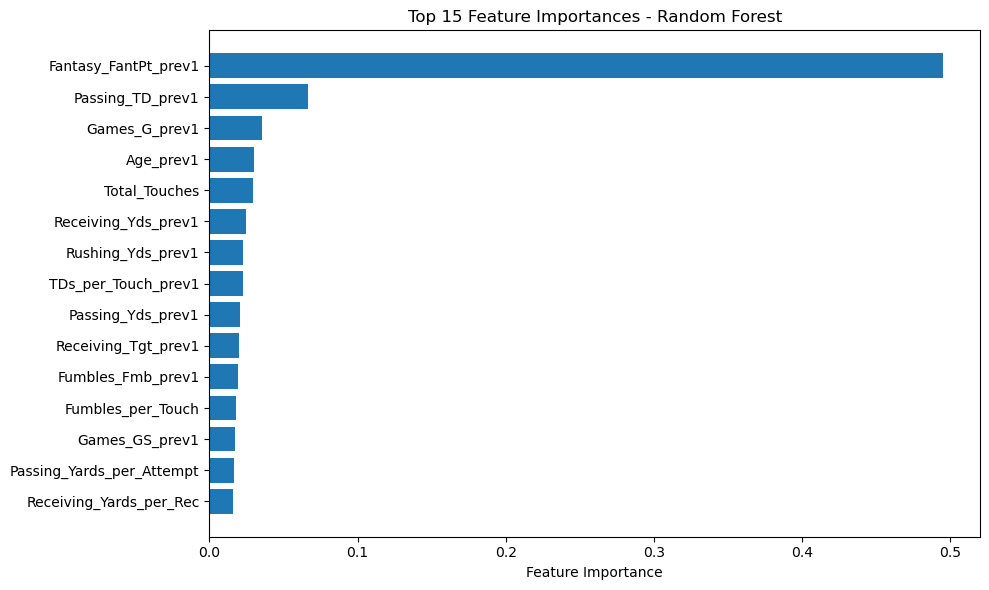

In [37]:
# Get and sort feature importances
importances = rf.feature_importances_
features = X_train.columns
indices = np.argsort(importances)[::-1]
sorted_features = [features[i] for i in indices]
sorted_importances = importances[indices]

# Plot top 15
plt.figure(figsize=(10, 6))
plt.barh(sorted_features[:15][::-1], sorted_importances[:15][::-1])
plt.xlabel("Feature Importance")
plt.title("Top 15 Feature Importances - Random Forest")
plt.tight_layout()
plt.show()

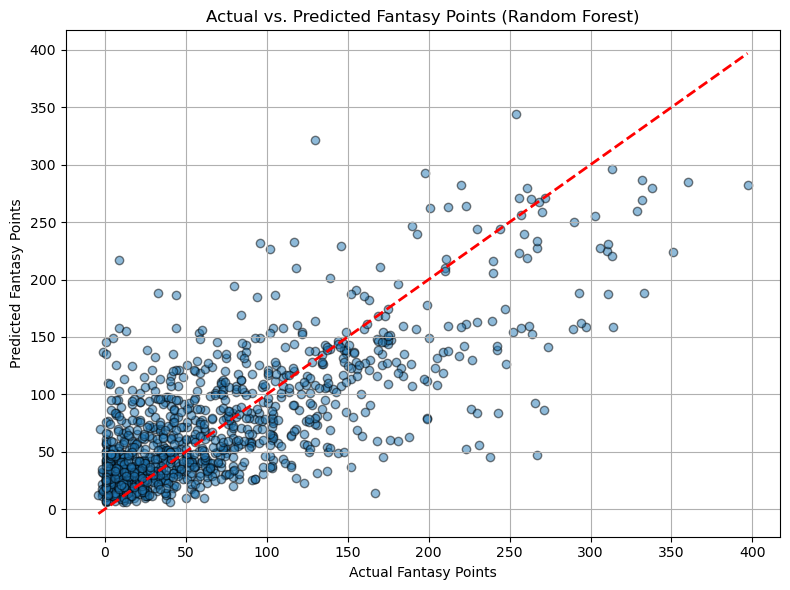

In [38]:
# Predictions already made earlier:
# y_pred_rf = rf.predict(X_test)

# Scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.5, edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Fantasy Points")
plt.ylabel("Predicted Fantasy Points")
plt.title("Actual vs. Predicted Fantasy Points (Random Forest)")
plt.grid(True)
plt.tight_layout()
plt.show()


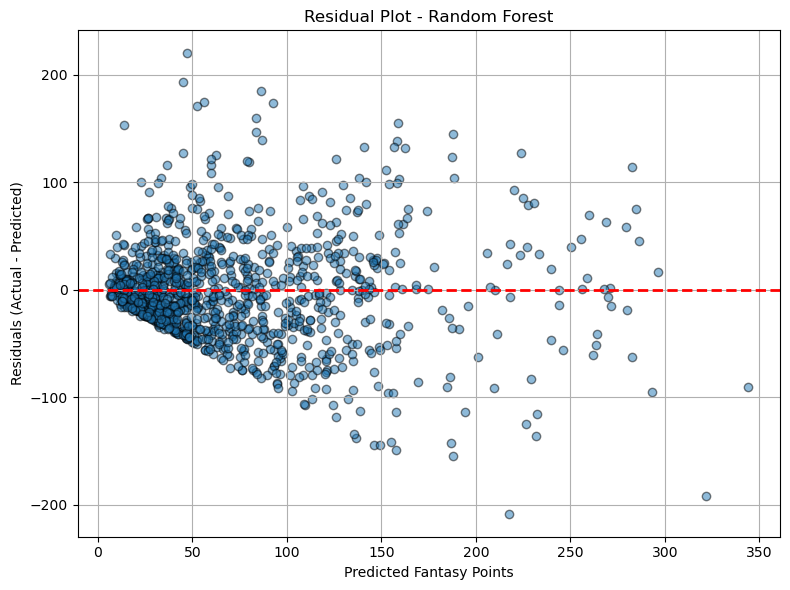

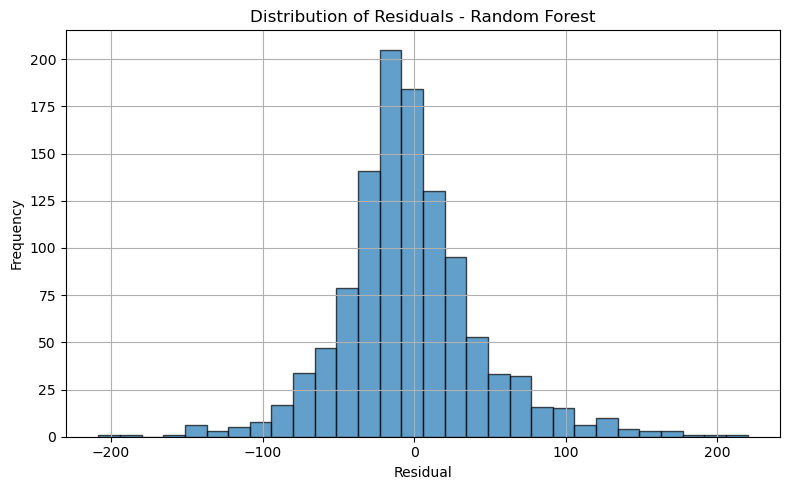

Mean      : -3.369
Median    : -7.200
Std Dev   : 47.176
Min       : -208.340
Max       : 219.820
Skewness  : 0.486

Sample residuals:
1205    -34.48
995     -12.78
1912     -3.19
4265    -36.25
5373    -72.10
1390     58.34
2606    123.78
5425     -2.74
5039    -50.42
662     -15.55
Name: Fantasy_FantPt, dtype: float64


In [39]:
# Compute residuals
residuals = y_test - y_pred_rf

# Residual scatterplot
plt.figure(figsize=(8, 6))
plt.scatter(y_pred_rf, residuals, alpha=0.5, edgecolors='k')
plt.axhline(0, color='r', linestyle='--', linewidth=2)
plt.xlabel("Predicted Fantasy Points")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot - Random Forest")
plt.grid(True)
plt.tight_layout()
plt.show()

# Residual distribution
plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=30, edgecolor='k', alpha=0.7)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals - Random Forest")
plt.grid(True)
plt.tight_layout()
plt.show()


# Quick stats
resid_summary = {
    "Mean": np.mean(residuals),
    "Median": np.median(residuals),
    "Std Dev": np.std(residuals),
    "Min": np.min(residuals),
    "Max": np.max(residuals),
    "Skewness": pd.Series(residuals).skew()
}

for k, v in resid_summary.items():
    print(f"{k:10}: {v:.3f}")

# Optional: show first 10 residuals
print("\nSample residuals:")
print(residuals[:10])

In [48]:
# 1) Use the exact training feature order
rf_features = getattr(rf, "feature_names_in_", list(X_train.columns))

# 2) Build 2025 feature matrix (using 2024 stats), fill NaNs same as training
X_2025_all = df.reindex(columns=rf_features).fillna(0)

# 3) Predict for all rows
preds_all = rf.predict(X_2025_all)

# 4) Attach identifiers + predictions
id_cols = [c for c in ["Player","PlayerName","Tm","FantPos","Season","Year"] if c in df.columns]
preds_df = df[id_cols].copy() if id_cols else pd.DataFrame(index=df.index)
preds_df["Predicted_FantPt_2025"] = preds_all

# 5) Keep only most recent season (2024) per player
preds_2025 = preds_df[preds_df["Season"] == 2024].copy()
preds_2025 = preds_2025.sort_values(["Player", "Season"]).drop_duplicates("Player", keep="last")

# 6) Keep only desired columns (drop Age_prev1)
keep_cols = [c for c in ["Player","Tm","FantPos","Predicted_FantPt_2025"] if c in preds_2025.columns]
preds_2025 = preds_2025[keep_cols]

# 7) Rank overall and by position
preds_2025 = preds_2025.sort_values("Predicted_FantPt_2025", ascending=False)
preds_2025["Rank_Overall"] = range(1, len(preds_2025) + 1)
if "FantPos" in preds_2025.columns:
    preds_2025["Rank_By_Pos"] = preds_2025.groupby("FantPos")["Predicted_FantPt_2025"] \
                                          .rank(method="first", ascending=False).astype(int)

# 8) Reset index so no confusing row numbers
preds_2025 = preds_2025.reset_index(drop=True)

# 9) Reorder columns like a leaderboard
col_order = ["Rank_Overall","Player","Tm","FantPos","Predicted_FantPt_2025","Rank_By_Pos"]
preds_2025 = preds_2025[col_order]

# 10) Save final 2025 projections
preds_2025.to_csv("rf_predictions_2025_FINAL_leaderboard.csv", index=False)
print("Saved rf_predictions_2025_FINAL_leaderboard.csv")
print(preds_2025.head(15))

Saved rf_predictions_2025_FINAL_leaderboard.csv
    Rank_Overall           Player   Tm FantPos  Predicted_FantPt_2025  \
0              1       Josh Allen  BUF      QB                 361.29   
1              2    Lamar Jackson  BAL      QB                 359.89   
2              3   Baker Mayfield  TAM      QB                 314.57   
3              4      Jalen Hurts  PHI      QB                 310.31   
4              5       Jared Goff  DET      QB                 293.14   
5              6      C.J. Stroud  HOU      QB                 282.55   
6              7       Joe Burrow  CIN      QB                 267.25   
7              8  Patrick Mahomes  KAN      QB                 262.59   
8              9   Justin Herbert  LAC      QB                 255.88   
9             10   Saquon Barkley  PHI      RB                 248.78   
10            11    Derrick Henry  BAL      RB                 239.83   
11            12       Geno Smith  SEA      QB                 239.39   
12 